In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV

import shap

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# DATASET

In [ ]:
#reels = pd.read_csv("/kaggle/input/datasets/filippotenani/classification-data/reels_extracted.csv")
reels = pd.read_csv("/content/reels_extracted (2).csv")

In [ ]:
reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Brand name', 'Industry',
       'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia',
       'first_face_position_ratio', 'motion_level', 'saturation', 'luminance',
       'contrast', 'sharpness', 'color_complexity', 'cognitive_overload',
       'flashiness', 'tone_video_api', 'voice_speed_video_api',
       'activity_video_api', 'format_video_api', 'product_integration_api',
       'funnel_api', 'posizionamento_api', 'hook_score_api',
       'microkinetics_video_api', 'tone_caption_api', 'funnel_caption_api',
       'caption_length', 'PERC_REACHED', 'ENGAGE_RATE', 'COMM_PER_LIKE'],
      dtype='object')

# TARGET VARIABLE

We want to classify the reels based on how much they stimulate conversation (comments) rather than just passive interactions (likes).

To do this we use the variable COMM_PER_LIKE (comments/likes) and define two classes: "Silent" and "Conversational", taken from the literature (we tried splitting into 3 categories but they were imbalanced or too noisy and the model performed poorly).

First we want to understand how to divide the target values (which have a strongly asymmetric distribution and the log doesn't seem to fix things) into the two categories, then we will build classification models.

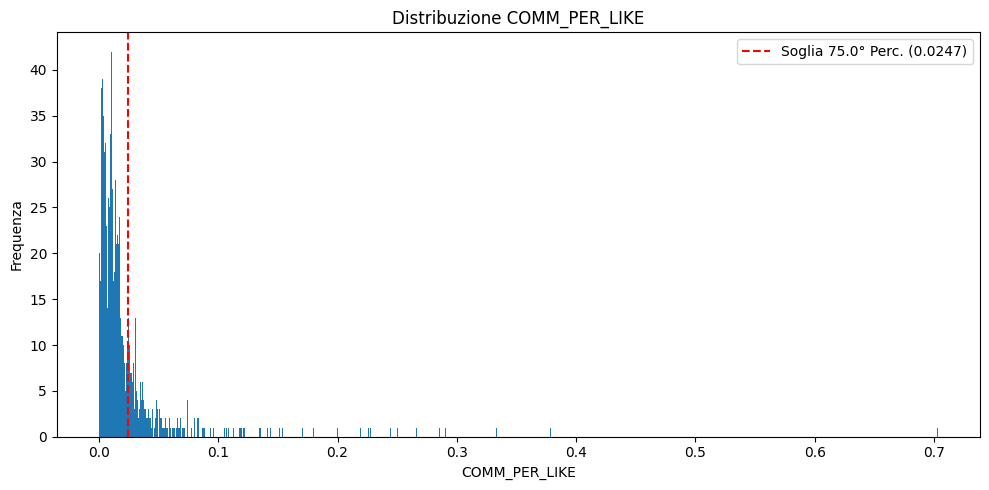

In [ ]:
# TARGET DISTRIBUTION

# choice of the cutoff threshold by percentile (chosen from the plot)
percentile_taglio = 0.75

# threshold computation based on the chosen percentile
soglia = reels['COMM_PER_LIKE'].quantile(percentile_taglio)

# we plot the target distribution
plt.figure(figsize=(10, 5))
plt.hist(reels['COMM_PER_LIKE'], bins=1000, edgecolor='none')

# vertical line on the percentile
plt.axvline(x=soglia, color='red', linestyle='--', label=f'Soglia {percentile_taglio*100}° Perc. ({soglia:.4f})')

plt.xlabel('COMM_PER_LIKE')
plt.ylabel('Frequenza')
plt.title(f'Distribuzione COMM_PER_LIKE')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Creation of the 2 classes based on the threshold seen from the previous plot
# we chose the 75th percentile threshold because it cuts after the peak
reels['CPL_class'] = pd.cut(
    reels['COMM_PER_LIKE'],
    bins=[-np.inf, soglia, np.inf],
    labels=[0, 1]
)

reels.groupby('CPL_class')['COMM_PER_LIKE'].describe()

/tmp/ipykernel_1233/3134803367.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reels.groupby('CPL_class')['COMM_PER_LIKE'].describe()


,count,mean,std,min,25%,50%,75%,max
CPL_class,,,,,,,,
0,736.0,0.010220,0.006393,0.000000,0.004665,0.009673,0.015169,0.024730
1,245.0,0.064008,0.071048,0.024791,0.030562,0.040816,0.062791,0.703271


# FEATURE SELECTION

The dataset has many variables, so before training the "actual" models we will use for prediction, we train a random forest on all variables (except irrelevant ones like social permalink etc.), then using Shapley Values we will identify the most important variables from the random forest and use these same ones to train more interpretable classification models.

In [ ]:
reels.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Brand name', 'Industry',
       'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio', 'faccia',
       'first_face_position_ratio', 'motion_level', 'saturation', 'luminance',
       'contrast', 'sharpness', 'color_complexity', 'cognitive_overload',
       'flashiness', 'tone_video_api', 'voice_speed_video_api',
       'activity_video_api', 'format_video_api', 'product_integration_api',
       'funnel_api', 'posizionamento_api', 'hook_score_api',
       'microkinetics_video_api', 'tone_caption_api', 'funnel_caption_api',
       'caption_length', 'PERC_REACHED', 'ENGAGE_RATE', 'COMM_PER_LIKE',
       'CPL_class'],
      dtype='object')

In [ ]:
# we keep only the features we can use in the model
features_rf = ['Creator name', 'Creator_gender', 'Followers', 'Type of content',
               'mese', 'Weekend/Settimanale', 'fascia_oraria', 'Reach','Brand name',
               'Industry', 'Local', 'Brand_SM', 'media_duration_sec', 'face_frame_ratio',
               'faccia', 'first_face_position_ratio', 'motion_level', 'saturation',
               'luminance', 'contrast', 'sharpness', 'color_complexity', 'tone_video_api',
               'voice_speed_video_api', 'activity_video_api', 'format_video_api',
               'product_integration_api', 'funnel_api', 'posizionamento_api', 'hook_score_api',
               'microkinetics_video_api', 'tone_caption_api', 'funnel_caption_api', 'caption_length']

# the target
target_rf = ['CPL_class']

In [ ]:
# ENCODING CATEGORICAL VARIABLES
# for categorical variables extracted by LLM that have a natural order we map the categories to numbers
# for the other categorical variables we use one hot encoding
# those with two categories we make binary without one hot encoding

# speech speed
# the only 'lenta' observation we treat as normal
reels['voice_speed_video_api'] = reels['voice_speed_video_api'].map({
    'assente': 0,
    'lenta':   1,
    'normale': 1,
    'veloce':  2
})

# hook strength
reels['hook_score_api'] = reels['hook_score_api'].map({
    'weak':   0,
    'medium': 1,
    'strong': 2
})

# brand positioning
# the 14 'non identificabile' we treat as accessibile (which is the mode)
reels['posizionamento_api'] = reels['posizionamento_api'].map({
    'non identificabile': 0,
    'accessibile':        0,
    'premium':            1,
    'lusso':              2
})

# binary
reels['Weekend/Settimanale'] = reels['Weekend/Settimanale'].map({'settimanale': 0, 'weekend': 1})
reels['Type of content'] = reels['Type of content'].map({'INSTAGRAM_REEL': 0, 'TIKTOK_POST': 1})

# for these others instead we do one hot encoding
cols_ohe = [
    'tone_video_api', 'activity_video_api', 'format_video_api',
    'microkinetics_video_api', 'tone_caption_api',
    'Creator_gender', 'mese', 'fascia_oraria', 'Industry',
    'funnel_api', 'funnel_caption_api', 'product_integration_api'
]
reels = pd.get_dummies(reels, columns=cols_ohe, dtype=int)

# make the target label to predict into integer
reels['CPL_class'] = reels['CPL_class'].astype(int)
reels['CPL_class'].dtypes

dtype('int64')

In [ ]:
# LOG TRANSFORMATION
# for Followers and Reach we take the log because they are skewed
reels["Reach_log"] = np.log1p(reels["Reach"])
reels["Followers_log"] = np.log1p(reels["Followers"])

In [ ]:
# features to use in the model
features_rf = [
    'Followers_log', 'Type of content', 'Weekend/Settimanale', 'Reach_log', 'Local', 'Brand_SM',
    'media_duration_sec', 'face_frame_ratio', 'faccia', 'first_face_position_ratio',
    'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity',
    'voice_speed_video_api', 'posizionamento_api', 'hook_score_api', 'caption_length',
    # OHE tone video
    'tone_video_api_calmo/confidenziale', 'tone_video_api_entusiasta/energico',
    'tone_video_api_ironico/scherzoso', 'tone_video_api_logico/informativo',
    'tone_video_api_neutro/assente',
    # OHE activity
    'activity_video_api_né parlato né attività', 'activity_video_api_parlato con attività',
    'activity_video_api_solo attività', 'activity_video_api_solo parlato',
    # OHE format
    'format_video_api_basic placement', 'format_video_api_brand-related experience/event',
    'format_video_api_product review', 'format_video_api_slice of life', 'format_video_api_tutorial',
    # OHE microkinetics
    'microkinetics_video_api_assente', 'microkinetics_video_api_authoritative_expert',
    'microkinetics_video_api_charismatic_performer', 'microkinetics_video_api_intimate_confidant',
    'microkinetics_video_api_soft_engager',
    # OHE tone caption
    'tone_caption_api_calmo/confidenziale', 'tone_caption_api_entusiasta/energico',
    'tone_caption_api_ironico/scherzoso', 'tone_caption_api_logico/informativo',
    'tone_caption_api_neutro/assente',
    # OHE gender
    'Creator_gender_f', 'Creator_gender_m', 'Creator_gender_o',
    # OHE mese
    'mese_agosto', 'mese_aprile', 'mese_dicembre', 'mese_febbraio', 'mese_gennaio',
    'mese_giugno', 'mese_luglio', 'mese_maggio', 'mese_marzo',
    'mese_novembre', 'mese_ottobre', 'mese_settembre',
    # OHE fascia oraria
    'fascia_oraria_cena', 'fascia_oraria_mattina', 'fascia_oraria_pomeriggio',
    'fascia_oraria_pranzo', 'fascia_oraria_sera',
    # OHE industry
    'Industry_Durables', 'Industry_Food', 'Industry_Health',
    'Industry_Lifestyle', 'Industry_Retail', 'Industry_Services',
    # OHE funnel
    'funnel_api_awareness', 'funnel_api_consideration', 'funnel_api_conversion',
    'funnel_caption_api_awareness', 'funnel_caption_api_consideration', 'funnel_caption_api_conversion',
    # OHE product integration
    'product_integration_api_assente', 'product_integration_api_in presentazione',
    'product_integration_api_in scena', 'product_integration_api_in uso',
]

# target
target_rf = 'CPL_class'

In [ ]:
# PREPARING X and y
X = reels[features_rf]
y = reels[target_rf]

## RANDOM FOREST

In [ ]:
# CROSS VALIDATION
# stratified to preserve class proportions
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# HYPERPARAMETER SEARCH SPACE
param_dist = {
    # number of trees
    'n_estimators': [100, 200, 300, 500],
    # maximum depth
    'max_depth': [5, 8, 10, 15, 20, 30, None],
    # minimum number of observations per leaf
    'min_samples_leaf': [10, 20, 30, 50],
    # maximum number of features considered by each tree in splits
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    # class_weight balanced to compensate for class 2 imbalance
    'class_weight': ['balanced'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# random search to find the best hyperparameters
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    # number of combinations to try in random search
    n_iter=50,
    # metrics we display
    scoring={'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted', 'accuracy': 'accuracy'},
    # the best model is chosen on macro F1 which computes F1 for each class and takes the unweighted average
    # useful because we have an imbalanced class 2
    refit='f1_macro',
    cv=cv,
    # for replicability
    random_state=42,
    # uses all available cores speeding up training
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

random_search.fit(X, y)

print("BEST PARAMS:", random_search.best_params_)
print(f"Best CV f1_macro: {random_search.best_score_:.3f}")

best_idx = random_search.best_index_

# train metrics
# to check if the model went into overfitting
print("TRAIN")
for metric in ['f1_macro', 'f1_weighted', 'accuracy']:
    train_mean = random_search.cv_results_[f'mean_train_{metric}'][best_idx]
    print(f"  {metric:<20} {train_mean:.3f}")

# validation metrics
print("\nVALIDATION")
for metric in ['f1_macro', 'f1_weighted', 'accuracy']:
    val_mean = random_search.cv_results_[f'mean_test_{metric}'][best_idx]
    val_std  = random_search.cv_results_[f'std_test_{metric}'][best_idx]
    print(f"  {metric:<20} {val_mean:.3f} ± {val_std:.3f}")

# FINAL FIT on the entire dataset for SHAP
rf = RandomForestClassifier(**random_search.best_params_, random_state=42, n_jobs=-1)
rf.fit(X, y);

BEST PARAMS: {'n_estimators': 200, 'min_samples_leaf': 20, 'max_features': 0.3, 'max_depth': 8, 'class_weight': 'balanced'}
Best CV f1_macro: 0.648
TRAIN
  f1_macro             0.777
  f1_weighted          0.827
  accuracy             0.822

VALIDATION
  f1_macro             0.648 ± 0.032
  f1_weighted          0.727 ± 0.024
  accuracy             0.720 ± 0.025


## SHAPLEY VALUES

                                            feature  mean_abs_shap
0                                         Reach_log       0.069207
1                                     Followers_log       0.052129
2                                  face_frame_ratio       0.035163
3                                    caption_length       0.030186
4                                      motion_level       0.012665
5                                        saturation       0.010564
6                  tone_video_api_ironico/scherzoso       0.010074
7                                   Type of content       0.009642
8                                         luminance       0.009308
9                                          contrast       0.008587
10                                         Brand_SM       0.007672
11                               media_duration_sec       0.006942
12                                 Creator_gender_f       0.006348
13                 funnel_caption_api_consideration       0.00

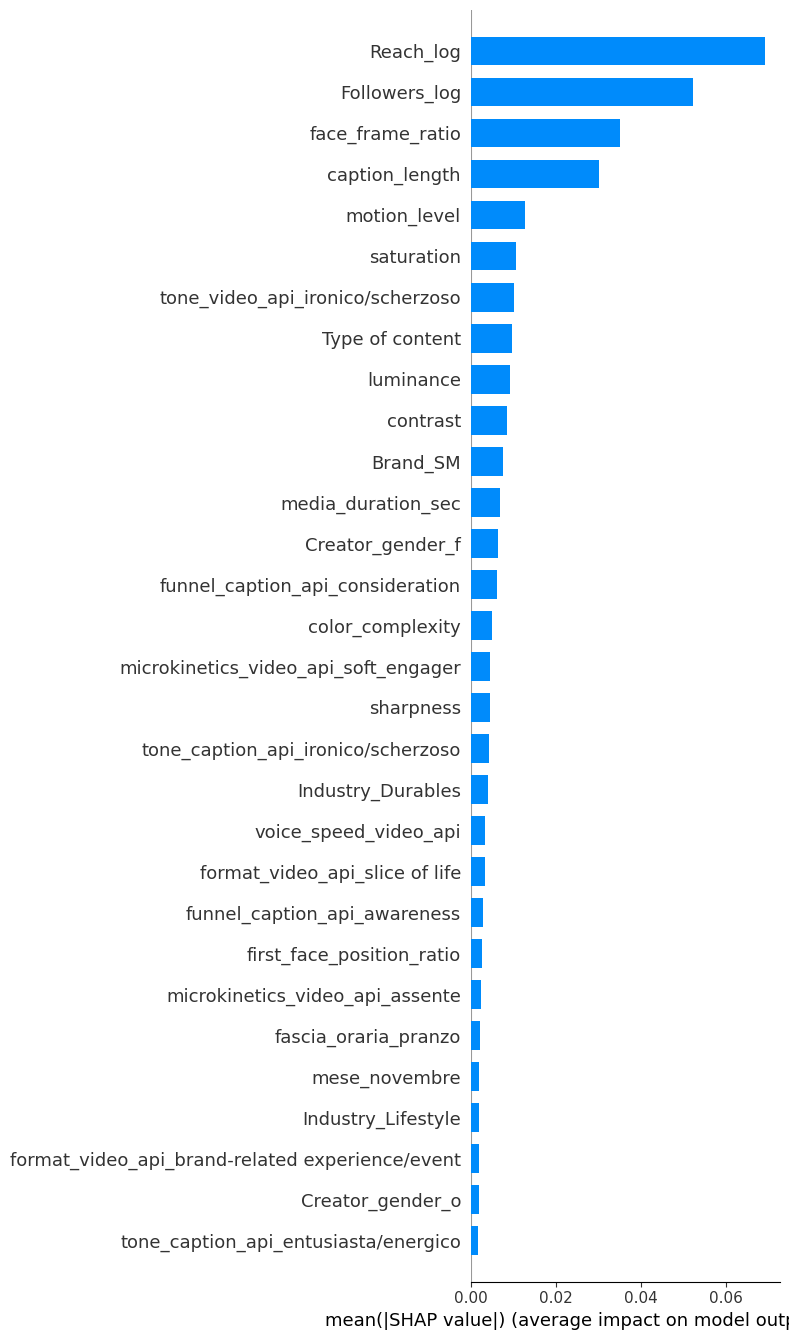

In [ ]:
# SHAPLEY VALUES

# TreeExplainer is SHAP optimized for tree-based models
explainer = shap.TreeExplainer(rf)
# compute shap values
shap_values = explainer.shap_values(X)

# for binary classification we extract shap values of the positive class
shap_values = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values[1]

# aggregate shap values across all observations to compute feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# let's see the 30 most important features
print(shap_importance.head(30))

# plot 30 most important features
shap.summary_plot(
    shap_values, X,
    plot_type='bar',
    max_display=30
)

In [ ]:
# mean shap values with sign (not absolute) to see direction
mean_shap = shap_values.mean(axis=0)

shap_direction = pd.DataFrame({
    'feature': X.columns,
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print(shap_direction)

                                            feature     mean_shap
0                tone_video_api_entusiasta/energico  9.552070e-05
1                                            faccia  0.000000e+00
2                                     mese_febbraio  0.000000e+00
3                                     mese_dicembre  0.000000e+00
4                                        mese_marzo  0.000000e+00
5                                fascia_oraria_sera  0.000000e+00
6                   product_integration_api_assente  0.000000e+00
7                                       mese_agosto  0.000000e+00
8                                       mese_aprile  0.000000e+00
9         activity_video_api_né parlato né attività  0.000000e+00
10               tone_video_api_calmo/confidenziale  0.000000e+00
11                                     mese_gennaio  0.000000e+00
12       microkinetics_video_api_intimate_confidant  0.000000e+00
13                 product_integration_api_in scena -1.083073e-07
14        

## FEATURE IMPORTANCE (SHAP Analysis)

The SHAP values from the Random Forest reveal a hierarchy of feature importance. All top features have negative mean SHAP values for class 1 (Conversational), meaning they predominantly push predictions toward the Silent class on average, consistent with class 1 being the minority.

### Top 10 most influential features (by absolute mean SHAP)

| Rank | Feature | Mean SHAP | Interpretation |
|------|---------|-----------|----------------|
| 1 | **Reach_log** | −0.0177 | Strongest predictor overall. Higher reach is associated with Silent posts, large-audience content accumulates likes passively without proportional comment engagement. |
| 2 | **Followers_log** | −0.0110 | Larger creators tend toward Silent content. As follower count grows, the comment-to-like ratio drops, engagement becomes more passive at scale. |
| 3 | **face_frame_ratio** | −0.0082 | More face presence in video frames pushes toward Silent. Face-heavy content may drive likes more than discussion. |
| 4 | **caption_length** | −0.0076 | Longer captions push toward Silent. This may seem counterintuitive, but long captions might satisfy the viewer's curiosity, reducing the need to comment. |
| 5 | **luminance** | −0.0040 | Brighter videos lean Silent. |
| 6 | **motion_level** | −0.0038 | Higher motion pushes toward Silent, fast-paced content may entertain passively rather than create discussion. |
| 7 | **saturation** | −0.0032 | More saturated videos lean Silent. |
| 8 | **media_duration_sec** | −0.0028 | Longer videos push toward Silent. Shorter content may be more provocative or leave more room for audience response. |
| 9 | **color_complexity** | −0.0024 | Higher visual complexity leans Silent. |
| 10 | **contrast** | −0.0023 | Higher contrast leans Silent. |

### Main patterns

- **Audience size dominates:** Reach and Followers are by far the two strongest predictors. This confirms that the comment-to-like ratio is fundamentally an audience-scale phenomenon where larger audiences drive disproportionately more likes than comments. This is a phenomenon well studied in literature: small creators have a more niche and devoted audience which tends to interact more than just liking the post.
- **Visual/production features cluster together:** luminance, saturation, contrast, sharpness, color_complexity, and motion_level all rank in the top 15 with similar negative effects. Highly produced and visually polished content tends to be consumed passively.
- **Content-level features have weak effects:** tone, format, funnel stage, product integration, and microkinetics all sit at the bottom of the ranking, meaning that how the video looks matters more than the what it says for predicting comment engagement.
- **Creator gender shows a mild effect:** female creators (−0.0010) slightly lean Silent, while group (−0.0003) and male (−0.0003) show weaker effects.
- **Platform matters modestly:** Type of content (−0.0016, where 1 = TikTok) suggests TikTok posts lean slightly more Silent than Instagram Reels.

In [ ]:
# WE TAKE THE MOST IMPORTANT FEATURES

# we will try the top 5/10/15/20/25/30 to see which subset performs best
top5  = shap_importance['feature'].head(5).tolist()
top10 = shap_importance['feature'].head(10).tolist()
top15 = shap_importance['feature'].head(15).tolist()
top20 = shap_importance['feature'].head(20).tolist()
top25 = shap_importance['feature'].head(25).tolist()
top30 = shap_importance['feature'].head(30).tolist()

features_selected = top5

# MODELS

Now we train models on the selected features to have less noise.

We try various models: XGBoost, Support Vector Machine, K-Nearest Neighbors, Logistic Regression, Naive Bayes.

We try different feature subsets: top5, top10, top15, top20, top25, top30.

In [ ]:
# CODE SHARED ACROSS ALL MODELS

# selected feature subset
X_sel = X[features_selected]

# scaling for SVM and logistic regression
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_sel),
    columns=features_selected
)

# cross validation and metrics shared across all models
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted', 'accuracy': 'accuracy'}

# function to print train and validation metrics
def print_cv_results(search):
    best_idx = search.best_index_
    print("BEST PARAMS:", search.best_params_)
    print("\nTRAIN")
    for metric in ['f1_macro', 'f1_weighted', 'accuracy']:
        train_mean = search.cv_results_[f'mean_train_{metric}'][best_idx]
        print(f"  {metric:<20} {train_mean:.3f}")
    print("\nVALIDATION")
    for metric in ['f1_macro', 'f1_weighted', 'accuracy']:
        val_mean = search.cv_results_[f'mean_test_{metric}'][best_idx]
        val_std  = search.cv_results_[f'std_test_{metric}'][best_idx]
        print(f"  {metric:<20} {val_mean:.3f} ± {val_std:.3f}")

## SVM

In [ ]:
# SVM

param_dist_svm = {
    # regularization: higher values means less regularization
    'C': [0.01, 0.1, 1, 10, 100],
    # kernel function to separate classes
    'kernel': ['linear', 'rbf'],
    # gamma for rbf kernel
    'gamma': ['scale', 'auto'],
    # balances classes based on their frequency
    'class_weight': ['balanced'],
}

# random search
search_svm = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring=scoring, refit='f1_macro',
    cv=cv, random_state=42,
    return_train_score=True, n_jobs=-1
)
search_svm.fit(X_scaled, y)
print_cv_results(search_svm)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=30. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


BEST PARAMS: {'kernel': 'linear', 'gamma': 'scale', 'class_weight': 'balanced', 'C': 0.1}

TRAIN
  f1_macro             0.640
  f1_weighted          0.716
  accuracy             0.704

VALIDATION
  f1_macro             0.636 ± 0.027
  f1_weighted          0.714 ± 0.020
  accuracy             0.703 ± 0.021


## KNN

In [ ]:
# KNN

param_dist_knn = {
    # number of neighbors
    'n_neighbors': [3, 5, 7, 10, 15, 20, 25, 30],
    # how to weight neighbors: uniform or by distance
    'weights': ['uniform'],
    # distance measure between observations
    'metric': ['euclidean', 'manhattan'],
}

# random search
search_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=30,
    scoring=scoring, refit='f1_macro',
    cv=cv, random_state=42,
    return_train_score=True, n_jobs=-1
)
search_knn.fit(X_scaled, y)
print_cv_results(search_knn)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=30. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


BEST PARAMS: {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'manhattan'}

TRAIN
  f1_macro             0.783
  f1_weighted          0.844
  accuracy             0.851

VALIDATION
  f1_macro             0.607 ± 0.028
  f1_weighted          0.719 ± 0.019
  accuracy             0.735 ± 0.018


## NAIVE BAYES

In [ ]:
# NAIVE BAYES

param_dist_nb = {
    # var_smoothing controls regularization
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
}

# random search
search_nb = RandomizedSearchCV(
    GaussianNB(),
    param_distributions=param_dist_nb,
    n_iter=7,
    scoring=scoring, refit='f1_macro',
    cv=cv, random_state=42,
    return_train_score=True, n_jobs=-1
)
search_nb.fit(X_sel, y)
print_cv_results(search_nb)

BEST PARAMS: {'var_smoothing': 1e-09}

TRAIN
  f1_macro             0.647
  f1_weighted          0.748
  accuracy             0.764

VALIDATION
  f1_macro             0.638 ± 0.027
  f1_weighted          0.742 ± 0.014
  accuracy             0.757 ± 0.009


## XGBOOST

In [ ]:
# XGBOOST
param_dist_xgb = {
    # number of ensemble trees
    'n_estimators': [100, 200, 300],
    # maximum depth of each tree
    'max_depth': [2, 3, 4, 5],
    # learning_rate
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # fraction of observations/rows sampled for each tree
    'subsample': [0.5, 0.6, 0.7, 0.8, 1.0],
    # fraction of features/columns per tree
    'colsample_bytree': [0.5, 0.7, 1.0],
    # minimum observations per leaf
    'min_child_weight': [5, 10, 20, 30],
    # compensates for class imbalance
    'scale_pos_weight': [y.value_counts()[0] / y.value_counts()[1]],
}

# random search
search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring=scoring, refit='f1_macro',
    cv=cv, random_state=42,
    return_train_score=True, n_jobs=-1
)

search_xgb.fit(X_sel, y)
print_cv_results(search_xgb)

BEST PARAMS: {'subsample': 0.7, 'scale_pos_weight': np.float64(3.0040816326530613), 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

TRAIN
  f1_macro             0.691
  f1_weighted          0.751
  accuracy             0.738

VALIDATION
  f1_macro             0.627 ± 0.043
  f1_weighted          0.698 ± 0.032
  accuracy             0.682 ± 0.032


## LOGISTIC REGRESSION

In [ ]:
# LOGISTIC REGRESSION

param_dist_lr = {
    # regularization: higher values means less regularization
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    # type of regularization (lasso, ridge)
    'penalty': ['l1', 'l2'],
    # optimization algorithm: liblinear supports both l1 and l2
    'solver': ['liblinear'],
    # balances classes based on their frequency
    'class_weight': ['balanced'],
}

# random search
search_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring=scoring, refit='f1_macro',
    cv=cv, random_state=42,
    return_train_score=True, n_jobs=-1
)
search_lr.fit(X_scaled, y)
print_cv_results(search_lr)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


BEST PARAMS: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 1}

TRAIN
  f1_macro             0.628
  f1_weighted          0.698
  accuracy             0.681

VALIDATION
  f1_macro             0.627 ± 0.028
  f1_weighted          0.697 ± 0.024
  accuracy             0.679 ± 0.025


## MODEL SELECTION

### Summary across all subsets of features (validation f1_macro)
The value of the f1_macro on the validation set for each model on each subset of features (top 5/10/15/20/25/30) including also the Random Forest used for feature selection.

| Model | TOP5 | TOP10 | TOP15 | TOP20 | TOP25 | TOP30 | Avg | Best |
|-------|------|-------|-------|-------|-------|-------|-----|------|
| RF (all features) | — | — | — | — | — | — | — | 0.648 |
| XGB | 0.627 | 0.634 | 0.642 | 0.644 | 0.648 | **0.649** | 0.641 | 0.649 |
| NB | **0.638** | 0.445 | 0.445 | 0.445 | 0.445 | 0.445 | 0.477 | 0.638 |
| SVM | 0.636 | 0.624 | 0.629 | 0.630 | 0.627 | 0.645 | 0.632 | 0.645 |
| KNN | 0.607 | 0.615 | 0.637 | 0.627 | 0.595 | 0.614 | 0.616 | 0.637 |
| LR | 0.627 | 0.622 | 0.612 | 0.618 | 0.620 | 0.620 | 0.620 | 0.627 |

### Overfitting analysis (train–validation gap on f1_macro)
The difference in f1_macro between validation and train across the best models on the best subsets in order to see if they overfit (train f1_macro much higher than validation f1_macro).

| Model | Subset | Val  | Train | Gap |
|-------|--------|------|-------|-----|
| NB | TOP5 | 0.638 | 0.647 | **0.009** |
| SVM | TOP5 | 0.636 | 0.640 | **0.004** |
| LR | TOP5 | 0.627 | 0.628 | **0.001** |
| RF | ALL | 0.648 | 0.777 | 0.129 |
| XGB | TOP30 | 0.649 | 0.897 | 0.248 |
| KNN | TOP15 | 0.637 | 0.799 | 0.162 |

### Model selection

We select **Gaussian Naive Bayes trained on the top 5 SHAP features** as the final model.

NB TOP5 achieves f1_macro = 0.638, f1_weighted = 0.742, and accuracy = 0.757 with a train–validation gap under 0.01. While XGB TOP30 reaches a marginally higher f1_macro (0.649), it does so with a train–validation gap of 0.248, which means poor generalization and unreliable real-world performance.

NB TOP5 is the best or near-best model across all three metrics simultaneously: it does not trade off accuracy for f1 or vice versa.

The model uses only 5 features (Reach_log, Followers_log, face_frame_ratio, caption_length, luminance), making it simple explain. Adding more features does not help NB (it collapses beyond TOP5 due to the independence assumption being violated by correlated OHE columns) and only marginally helps other models while dramatically increasing overfitting.

Finally Naive Bayes is a very interpretable model, which aligns with the project's goal of understanding what drives conversational engagement.

### Other good choices

- **SVM (linear, TOP5):** Nearly as stable (gap 0.004) as NB with f1_macro = 0.636, a strong alternative.
- **Random Forest (all features):** f1_macro = 0.648 with moderate overfitting (gap 0.129). Useful as the feature selection backbone (via SHAP) but too heavy and overfit to serve as the final classifier.
- **XGBoost:** Best raw f1_macro but severely overfit across all subsets, not recommended with a dataset this small.